# SQL in Python - Connecting to and retrieving data from PostgreSQL

Previously, you have learned how to connect to a SQL database by using a SQL client such as DBeaver. Apart from connecting to databases, DBeaver also allows you to run SQL queries against the database, create new tables and populate them with data as well as retrieving the data.

Python also allows executing SQL queries and getting the result into a Python object, for example a Pandas data frame. Instead of exporting a .csv file from DBeaver you can directly get the data you need into Python and continue your work. In addition we can reduce the steps by connecting to the database from Python directly, eliminating the need for a separate SQL client.

After you have the data in Python in the required shape you can export the data into a .csv file. This file is for your own reference, please avoid sending .csv files around - database is the point of reference when it comes to data. 

Having a copy of a .csv file (or another format) can speed up your analysis work. Imagine that the query takes 25 minutes to run. If you made some mistakes in your Python code you might need to go back to the original dataset. Instead of having to rerun the SQL query and having to wait you can read in the .csv file you have previously saved on your hard disk into Python and continue with your analysis work. 

**In this notebook you will see 2 ways to connect to SQL-Databases and export the data to a CSV file**


## Creating a connection to a PostgreSQL database with Python

There are 2 python packages that are the "go-to" when it comes to connecting to SQL-Databases: `psycopg2` and `sqlalchemy` 

### Connecting via psycopg2

In [1]:
import pandas as pd
import psycopg2


In order to create a connection to our PostgreSQL database we need the following information:

- host = the address of the machine the database is hosted on
- port = the virtual gate number through which communication will be allowed
- database = the name of the database
- user = the name of the user
- password = the password of the user

Because we don't want that the database information is published on github we put it into a `.env` file which is added into the `.gitignore`. 
In these kind of files you can store information that is not supposed to be published.
With the `dotenv` package you can read the `.env` files and get the variables.
(We will share the file with you on Slack!)


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

DATABASE = os.getenv('DATABASE')
USER_DB = os.getenv('USER_DB')
PASSWORD = os.getenv('PASSWORD')
HOST = os.getenv('HOST')
PORT = os.getenv('PORT')

print(DATABASE)

postgres


The function from the psycopg2 package to create a connection is called `connect()`.
`connect()` expects the parameters listed above as input in order to connect to the database.

In [3]:
# Create connection object conn
conn = psycopg2.connect(
    database=DATABASE,
    user=USER_DB,
    password=PASSWORD,
    host=HOST,
    port=PORT
)

### Retrieving data from the database with psycopg2

Before we can use our connection to get data, we have to create a cursor. A cursor allows Python code to execute PostgreSQL commmands in a database session.
A cursor has to be created with the `cursor()` method of our connection object conn.

In [4]:
cur = conn.cursor()

Now we can run SQL-Queries with `cur.execute('QUERY')` and then run `cur.fetchall()` to get the data:

In [5]:
cur.execute("""
                SET SCHEMA 'eda';
                SELECT kchd.*, kchs."date", kchs.price
                FROM king_county_house_details kchd
                LEFT JOIN king_county_house_sales kchs
                ON kchd.id = kchs.house_id;
""")
cur.fetchall()

[(7129300520,
  3.0,
  1.0,
  1180.0,
  5650.0,
  1.0,
  None,
  0.0,
  3,
  7,
  1180.0,
  0.0,
  1955,
  0,
  98178,
  47.5112,
  -122.257,
  1340.0,
  5650.0,
  datetime.date(2014, 10, 13),
  221900.0),
 (6414100192,
  3.0,
  2.25,
  2570.0,
  7242.0,
  2.0,
  0.0,
  0.0,
  3,
  7,
  2170.0,
  400.0,
  1951,
  19910,
  98125,
  47.721,
  -122.319,
  1690.0,
  7639.0,
  datetime.date(2014, 12, 9),
  538000.0),
 (5631500400,
  2.0,
  1.0,
  770.0,
  10000.0,
  1.0,
  0.0,
  0.0,
  3,
  6,
  770.0,
  0.0,
  1933,
  None,
  98028,
  47.7379,
  -122.233,
  2720.0,
  8062.0,
  datetime.date(2015, 2, 25),
  180000.0),
 (2487200875,
  4.0,
  3.0,
  1960.0,
  5000.0,
  1.0,
  0.0,
  0.0,
  5,
  7,
  1050.0,
  910.0,
  1965,
  0,
  98136,
  47.5208,
  -122.393,
  1360.0,
  5000.0,
  datetime.date(2014, 12, 9),
  604000.0),
 (1954400510,
  3.0,
  2.0,
  1680.0,
  8080.0,
  1.0,
  0.0,
  0.0,
  3,
  8,
  1680.0,
  0.0,
  1987,
  0,
  98074,
  47.6168,
  -122.045,
  1800.0,
  7503.0,
  datetime.

With `conn.close()` you can close the connection again.

In [7]:
#close the connection
conn.close()

But we want to work with the data. The easiest way is to import the data into pandas dataframes. We can use `pd.read_sql_query` or `pd.read_sql_table` or for convenience `pd.read_sql`.

This function is a convenience wrapper around read_sql_table and read_sql_query (for backward compatibility). It will delegate to the specific function depending on the provided input. A SQL query will be routed to read_sql_query , while a database table name will be routed to read_sql_table . Note that the delegated function might have more specific notes about their functionality not listed here.

In [8]:
# Open connection again because we closed it
conn = psycopg2.connect(
    database=DATABASE,
    user=USER_DB,
    password=PASSWORD,
    host=HOST,
    port=PORT
)

In [9]:
# import the data into a pandas dataframe
query_string =  """
SET SCHEMA 'eda';
SELECT kchd.*, kchs."date", kchs.price
FROM king_county_house_details kchd
LEFT JOIN king_county_house_sales kchs
ON kchd.id = kchs.house_id;
"""
df_psycopg = pd.read_sql(query_string, conn)

/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_9595/3548510518.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_psycopg = pd.read_sql(query_string, conn)


In [10]:
#close the connection
conn.close()

In [11]:
df_psycopg.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0


In [12]:
#export the data to a csv-file
df_psycopg.to_csv('data/eda.csv',index=False)

### Connecting and retrieving data via SQLAlchemy

`sqlalchemy` works similarly. Here you have to create an engine with the database sting (a link that includes every information we entered in the conn object)

In [13]:
from sqlalchemy import create_engine

#read the database string from the .env
load_dotenv()

DB_STRING = os.getenv('DB_STRING')

db = create_engine(DB_STRING)

And then you can import that engine with a query into a pandas dataframe.

In [14]:
#import the data to a pandas dataframe
query_string = "SELECT * FROM eda.king_county_house_sales"
df_sqlalchemy = pd.read_sql(query_string, db)

/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_9595/2322756132.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sqlalchemy = pd.read_sql(query_string, db)


AttributeError: 'Engine' object has no attribute 'cursor'

In [15]:
df_sqlalchemy.head()

NameError: name 'df_sqlalchemy' is not defined

Because we don't want to run the queries over and over again we can export the data into a .csv file in order to use it in other notebooks as well. 

In [16]:
#export the data to a csv-file
df_sqlalchemy.to_csv('eda.csv',index=False)

NameError: name 'df_sqlalchemy' is not defined

In [17]:
#import the data from a csv-file
df_import = pd.read_csv('data/eda.csv')

In [18]:
df = pd.read_csv('data/eda.csv')
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df_property = pd.read_csv('data/eda.csv')
df_property.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,1955,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,400.0,1951,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,0.0,1933,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,910.0,1965,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,1987,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0


In [21]:
df_property.columns = df_property.columns.str.replace(' ','_')
df_property.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price'],
      dtype='str')

In [22]:
df_property.duplicated().value_counts()

False    21597
Name: count, dtype: int64

In [23]:
df_property.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float64
 18  sqft_lot15     21

In [25]:
df_property.dtypes

id                 int64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition          int64
grade              int64
sqft_above       float64
sqft_basement    float64
yr_built           int64
yr_renovated     float64
zipcode            int64
lat              float64
long             float64
sqft_living15    float64
sqft_lot15       float64
date                 str
price            float64
dtype: object

In [26]:
type(df_property['date'][0])

str

In [27]:
# change "date" dtype to datetime with format %Y/%m/%d
df_property['date'] = pd.to_datetime(df_property['date'], format = '%Y-%m-%d')

In [28]:
type(df_property['date'][0])

pandas.Timestamp

In [ ]:
# To see the top 10 highest priced houses
top_houses = df_property.nlargest(10, 'price')

print(top_houses[['price', 'zipcode', 'lat', 'long']])

          price  zipcode      lat     long
7245  7700000.0    98102  47.6298 -122.323
3910  7060000.0    98004  47.6500 -122.214
9245  6890000.0    98039  47.6305 -122.240
4407  5570000.0    98039  47.6289 -122.233
1446  5350000.0    98004  47.6232 -122.220
1313  5300000.0    98040  47.5631 -122.210
1162  5110000.0    98033  47.6767 -122.211
8085  4670000.0    98040  47.5570 -122.210
2624  4500000.0    98155  47.7493 -122.280
8629  4490000.0    98004  47.6208 -122.219


In [30]:
# Get locations of the top 10 most expensive houses
locations = top_houses[['price', 'zipcode', 'lat', 'long']]
print(locations)

          price  zipcode      lat     long
7245  7700000.0    98102  47.6298 -122.323
3910  7060000.0    98004  47.6500 -122.214
9245  6890000.0    98039  47.6305 -122.240
4407  5570000.0    98039  47.6289 -122.233
1446  5350000.0    98004  47.6232 -122.220
1313  5300000.0    98040  47.5631 -122.210
1162  5110000.0    98033  47.6767 -122.211
8085  4670000.0    98040  47.5570 -122.210
2624  4500000.0    98155  47.7493 -122.280
8629  4490000.0    98004  47.6208 -122.219


In [32]:
# Calculate the center point for latitude and longitude
center_lat = df_property['lat'].mean()
center_long = df_property['long'].mean()

print(f"The center of the dataset is at: {center_lat}, {center_long}")

The center of the dataset is at: 47.56009299439737, -122.21398254294577


In [33]:
# Finding the house closest to the average center
center_house = df_property.iloc[((df_property['lat'] - center_lat)**2 + 
                                 (df_property['long'] - center_long)**2).idxmin()]

print(f"The center is near Zip Code: {center_house['zipcode']}")

The center is near Zip Code: 98040


In [34]:
df_property.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
count,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,19206.000000,21534.000000,21597.000000,21597.000000,...,21145.000000,21597.000000,17749.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597,2.159700e+04
mean,4.580474e+09,3.373200,2.115826,2080.321850,1.509941e+04,1.494096,0.007602,0.233863,3.409825,7.657915,...,291.857224,1970.999676,836.650516,98077.951845,47.560093,-122.213983,1986.620318,12758.283512,2014-10-29 04:20:38.171968,5.402966e+05
min,1.000102e+06,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,3.000000,...,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000,2014-05-02 00:00:00,7.800000e+04
25%,2.123049e+09,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,...,0.000000,1951.000000,0.000000,98033.000000,47.471100,-122.328000,1490.000000,5100.000000,2014-07-22 00:00:00,3.220000e+05
50%,3.904930e+09,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,...,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.231000,1840.000000,7620.000000,2014-10-16 00:00:00,4.500000e+05
75%,7.308900e+09,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,0.000000,4.000000,8.000000,...,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000,2015-02-17 00:00:00,6.450000e+05
max,9.900000e+09,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,...,4820.000000,2015.000000,20150.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000,2015-05-27 00:00:00,7.700000e+06
std,2.876736e+09,0.926299,0.768984,918.106125,4.141264e+04,0.539683,0.086858,0.765686,0.650546,1.173200,...,442.490863,29.375234,4000.110554,53.513072,0.138552,0.140724,685.230472,27274.441950,NaN,3.673681e+05


In [35]:
# Returns the count of missing values per column
df_property.isnull().sum()

id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
date                0
price               0
dtype: int64

<Axes: >

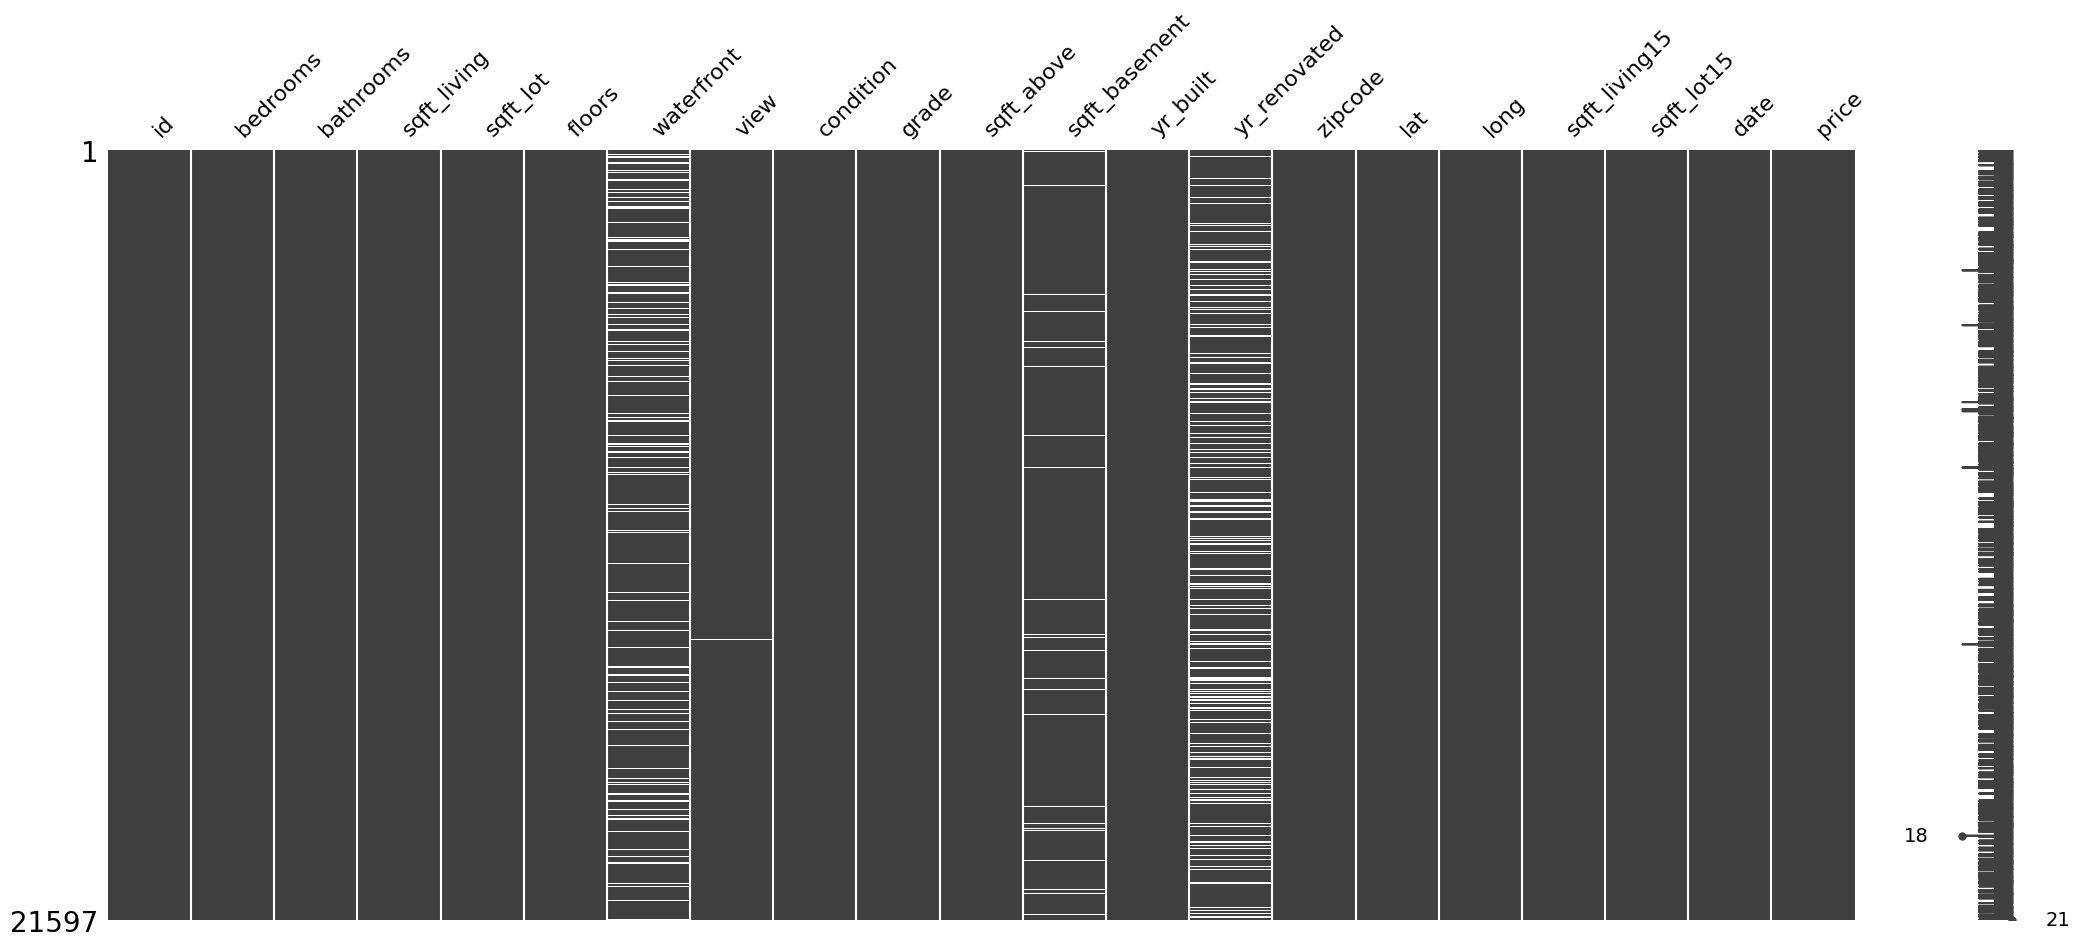

In [36]:
import missingno as msno

# Visualizes the location of missing values
msno.matrix(df_property)

<Axes: >

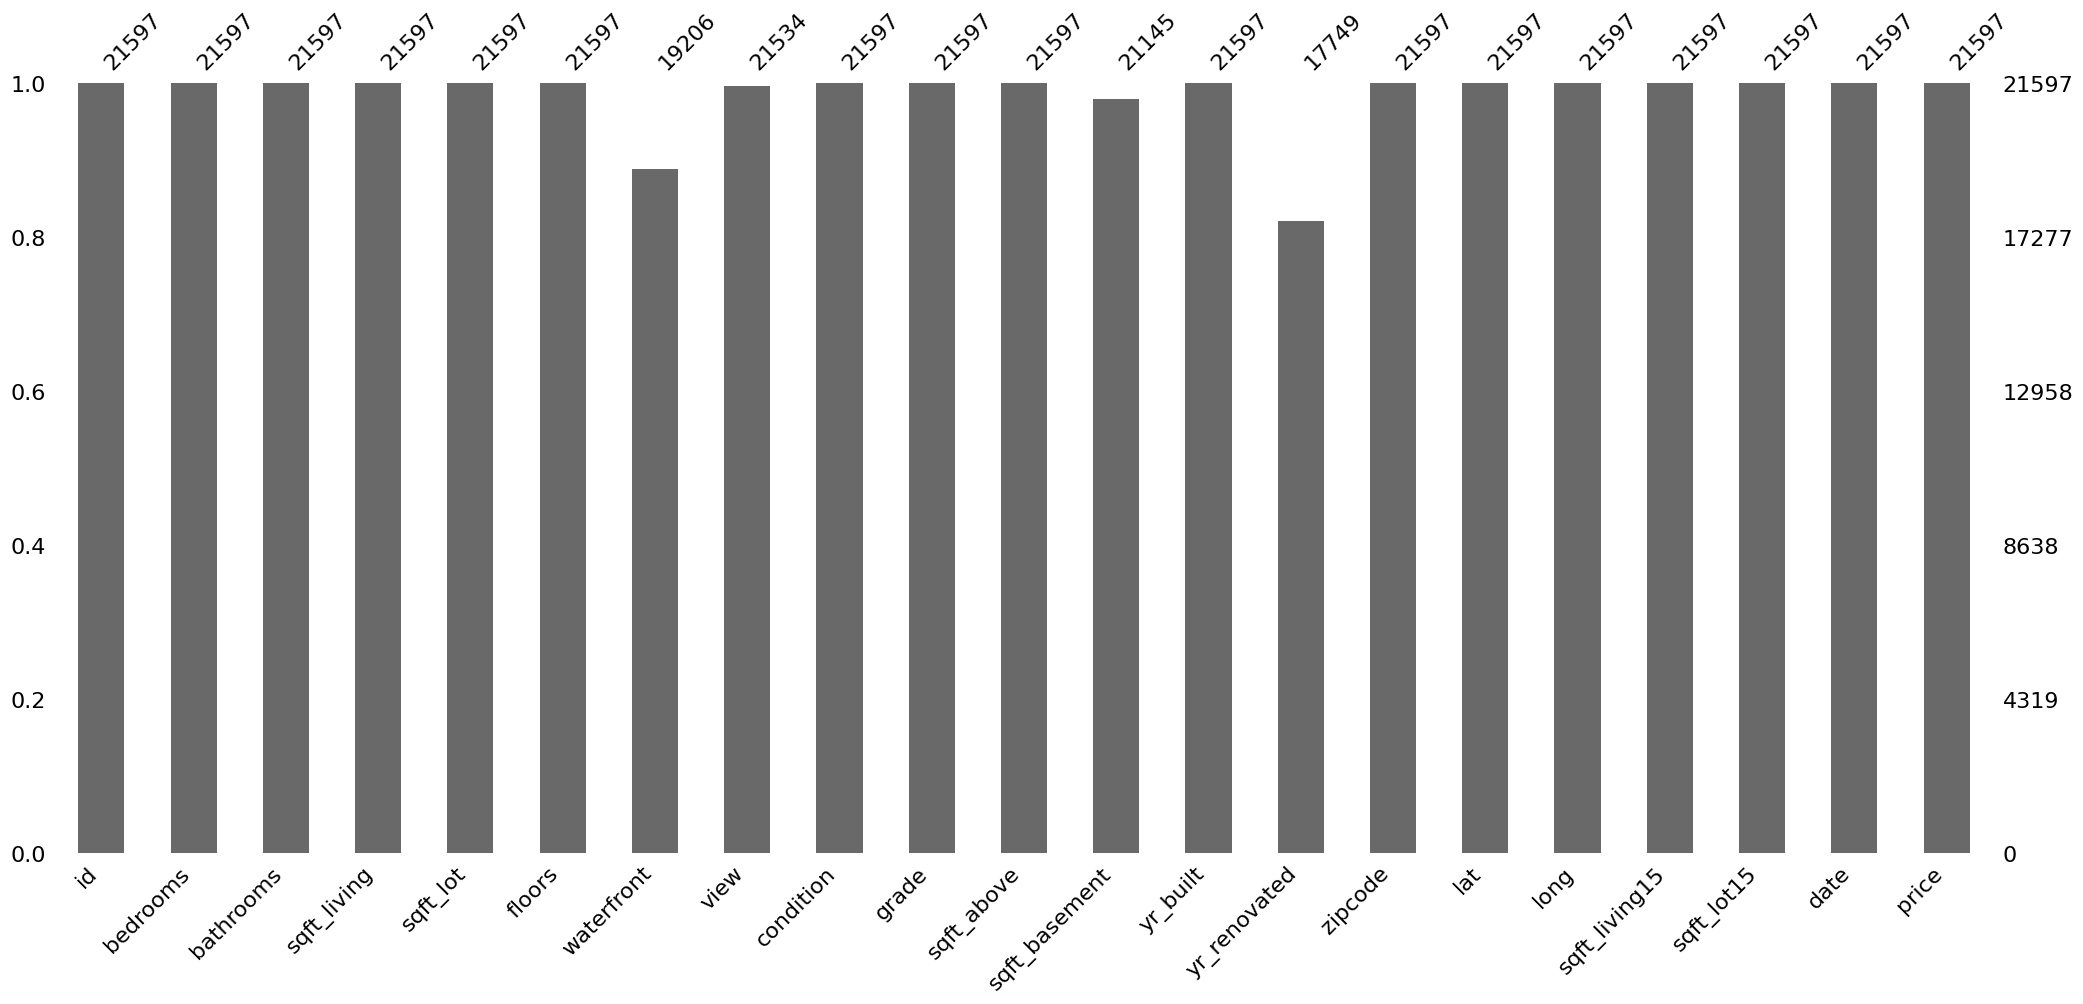

In [37]:
msno.bar(df_property)

In [38]:
df_property['waterfront'] = df_property['waterfront'].fillna(0, inplace=True)
df_property['view'] = df_property['view'].fillna(df_property['view'].mode()[0])
df_property['sqft_basement'] = df_property['sqft_basement'].fillna(0)
df_property['yr_renovated'] = df_property['yr_renovated'].fillna(0)

/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_9595/2905862259.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_property['waterfront'] = df_property['waterfront'].fillna(0, inplace=True)


In [39]:
df_property['yr_renovated'].unique()

array([    0., 19910., 20020., 20100., 19920., 20130., 19940., 19780.,
       20050., 20030., 19840., 19540., 20140., 20110., 19830., 19450.,
       19900., 19880., 19770., 19810., 19950., 20000., 19990., 19980.,
       19700., 19890., 20040., 19860., 20070., 19870., 20060., 19850.,
       20010., 19800., 19710., 19790., 19970., 19500., 19690., 19480.,
       20090., 20150., 19740., 20080., 19680., 20120., 19630., 19510.,
       19620., 19530., 19930., 19960., 19550., 19820., 19560., 19400.,
       19760., 19460., 19750., 19640., 19730., 19570., 19590., 19600.,
       19670., 19650., 19340., 19720., 19440., 19580.])

In [86]:
# The correct way to fix the systematic "extra zero" error
# We divide by 10 for any value that is clearly a "year + extra zero"
df_property['yr_renovated'] = df_property['yr_renovated'].apply(lambda x: x / 10 if x > 2026 else x)

# Now check the results
print("Corrected Renovation Years:")
print(df_property[df_property['yr_renovated'] > 0]['yr_renovated'].unique())

Corrected Renovation Years:
[1991. 2002. 2010. 1992. 2013. 1994. 1978. 2005. 2003. 1984. 1954. 2014.
 2011. 1983. 1945. 1990. 1988. 1977. 1981. 1995. 2000. 1999. 1998. 1970.
 1989. 2004. 1986. 2007. 1987. 2006. 1985. 2001. 1980. 1971. 1979. 1997.
 1950. 1969. 1948. 2009. 2015. 1974. 2008. 1968. 2012. 1963. 1951. 1962.
 1953. 1993. 1996. 1955. 1982. 1956. 1940. 1976. 1946. 1975. 1964. 1973.
 1957. 1959. 1960. 1967. 1965. 1934. 1972. 1944. 1958.]


In [40]:
df_property.zipcode.nunique()

70

In [41]:
df_property['zipcode'].unique()

array([98178, 98125, 98028, 98136, 98074, 98053, 98003, 98198, 98146,
       98038, 98007, 98115, 98107, 98126, 98019, 98103, 98002, 98133,
       98040, 98092, 98030, 98119, 98112, 98052, 98027, 98117, 98058,
       98001, 98056, 98166, 98023, 98070, 98148, 98105, 98042, 98008,
       98059, 98122, 98144, 98004, 98005, 98034, 98075, 98116, 98010,
       98118, 98199, 98032, 98045, 98102, 98077, 98108, 98168, 98177,
       98065, 98029, 98006, 98109, 98022, 98033, 98155, 98024, 98011,
       98031, 98106, 98072, 98188, 98014, 98055, 98039])

In [42]:
df_property.isnull().sum()

id               0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
date             0
price            0
dtype: int64

In [129]:
print("Cleaning complete. Current missing values:")
print(df_property.isnull().sum().sum())

Cleaning complete. Current missing values:
0


In [43]:
# Identify the Geographic Center (Median Lat/Long)
center_lat = df_property['lat'].median()
center_lat

np.float64(47.5718)

In [44]:
# Identify the Geographic Center (Median Long)
center_long = df_property['long'].median()
center_long

np.float64(-122.231)

In [45]:
#Extract time features
df_property['month'] = df_property['date'].dt.month
df_property['month_name'] = df_property['date'].dt.month_name()

In [46]:
df_property['month']

0        10
1        12
2         2
3        12
4         2
         ..
21592     5
21593     2
21594     6
21595     1
21596    10
Name: month, Length: 21597, dtype: int32

In [47]:
df_property['month_name']

0         October
1        December
2        February
3        December
4        February
           ...   
21592         May
21593    February
21594        June
21595     January
21596     October
Name: month_name, Length: 21597, dtype: str

In [48]:
#Calculate Distance from Center
df_property['dist_from_center'] = np.sqrt((df_property['lat'] - center_lat)**2 + (df_property['long'] - center_long)**2)

In [49]:
df_property['dist_from_center']

0        0.065942
1        0.173218
2        0.166112
3        0.169838
4        0.191366
           ...   
21592    0.171701
21593    0.144548
21594    0.071657
21595    0.166239
21596    0.071563
Name: dist_from_center, Length: 21597, dtype: float64

In [50]:
#Central and Expensive
price_75th = df_property['price'].quantile(0.75)
price_75th

np.float64(645000.0)

In [51]:
df_property['is_central'] = df_property['dist_from_center'] < 0.1
df_property['is_central']

0         True
1        False
2        False
3        False
4        False
         ...  
21592    False
21593    False
21594     True
21595    False
21596     True
Name: is_central, Length: 21597, dtype: bool

In [76]:
df_property['is_central'].value_counts()

is_central
False    17930
True      3667
Name: count, dtype: int64

In [52]:
df_property['is_expensive'] = df_property['price'] > price_75th
df_property['is_expensive']

0        False
1        False
2        False
3        False
4        False
         ...  
21592    False
21593    False
21594    False
21595    False
21596    False
Name: is_expensive, Length: 21597, dtype: bool

In [72]:
# Returns the total number of True values
df_property['is_expensive'].sum()

np.int64(5371)

In [73]:
# Shows a breakdown of True vs False
df_property['is_expensive'].value_counts()

is_expensive
False    16226
True      5371
Name: count, dtype: int64

In [77]:
# Counting how many properties meet both conditions
both_true_count = ((df_property['is_central'] == True) & (df_property['is_expensive'] == True)).sum()

print(f"Number of properties that are both central and expensive: {both_true_count}")

Number of properties that are both central and expensive: 1545


In [78]:
# Creating a filtered dataframe for Timothy's specific segment
timothy_segment = df_property[(df_property['is_central'] == True) & (df_property['is_expensive'] == True)]

# Display the first few rows
timothy_segment.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_living15,sqft_lot15,date,price,month,month_name,dist_from_center,is_central,is_expensive,is_renovated
10,1736800520,3.0,2.50,3560.0,9796.0,1.0,0.0,0.0,3,8,...,2210.0,8925.0,2015-04-03,662500.0,4,April,0.090726,True,True,False
21,2524049179,3.0,2.75,3050.0,44867.0,1.0,0.0,4.0,3,9,...,4110.0,20336.0,2014-08-26,2000000.0,8,August,0.040250,True,True,False
27,3303700376,3.0,1.00,1400.0,1581.0,1.5,0.0,0.0,5,8,...,1860.0,3861.0,2014-12-01,667000.0,12,December,0.097052,True,True,False
47,4178300310,4.0,2.50,2290.0,13416.0,2.0,0.0,0.0,4,9,...,2680.0,13685.0,2014-07-16,785000.0,7,July,0.093090,True,True,False
54,4217401195,5.0,2.25,2730.0,6000.0,1.5,0.0,0.0,3,8,...,2730.0,6000.0,2015-03-03,920000.0,3,March,0.098874,True,True,False


In [53]:
df_property['is_renovated'] = df_property['yr_renovated'] > 0
df_property['is_renovated']

0        False
1         True
2        False
3        False
4        False
         ...  
21592    False
21593    False
21594    False
21595    False
21596    False
Name: is_renovated, Length: 21597, dtype: bool

In [74]:
df_property['is_renovated'].value_counts()

is_renovated
False    20853
True       744
Name: count, dtype: int64

In [54]:
df_property['grade'].unique()


array([ 7,  6,  8, 11,  9,  5, 10, 12,  4,  3, 13])

In [55]:
# 1. Create a new dataframe containing only houses with grade > 9
high_grade_houses = df_property[df_property['grade'] > 9]
high_grade_houses

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_living15,sqft_lot15,date,price,month,month_name,dist_from_center,is_central,is_expensive,is_renovated
5,7237550310,4.0,4.50,5420.0,101930.0,1.0,0.0,0.0,3,11,...,4760.0,101930.0,2014-05-12,1230000.0,5,May,0.241210,False,True,False
66,3394100030,4.0,2.50,2720.0,11049.0,2.0,0.0,0.0,3,10,...,2750.0,11049.0,2014-09-09,975000.0,9,September,0.040188,True,True,False
70,1525059190,5.0,3.25,4770.0,50094.0,1.0,0.0,0.0,4,11,...,3530.0,38917.0,2014-09-12,1040000.0,9,September,0.107487,False,True,False
75,3276920270,4.0,4.00,3430.0,35102.0,2.0,0.0,0.0,4,10,...,3240.0,35020.0,2014-11-05,832500.0,11,November,0.244222,False,True,False
79,1531000030,4.0,2.50,3450.0,39683.0,2.0,0.0,0.0,3,10,...,3350.0,39750.0,2015-03-23,720000.0,3,March,0.308616,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21560,9253900271,5.0,4.50,4850.0,10584.0,2.0,1.0,4.0,3,10,...,3470.0,18270.0,2015-01-07,3570000.0,1,January,0.123074,False,True,False
21574,7430200100,4.0,3.50,4910.0,9444.0,1.5,0.0,0.0,3,11,...,4560.0,11063.0,2014-05-14,1220000.0,5,May,0.182679,False,True,False
21577,8672200110,5.0,3.75,4170.0,8142.0,2.0,0.0,2.0,3,10,...,3030.0,7980.0,2015-03-17,1090000.0,3,March,0.061846,True,True,False
21581,191100405,4.0,3.25,3410.0,10125.0,2.0,0.0,0.0,3,10,...,2290.0,10125.0,2015-04-21,1580000.0,4,April,0.010308,True,True,False


In [56]:
high_grade_houses.sort_values(by='price', ascending=False).head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_living15,sqft_lot15,date,price,month,month_name,dist_from_center,is_central,is_expensive,is_renovated
7245,6762700020,6.0,8.00,12050.0,27600.0,2.5,0.0,3.0,4,13,...,3940.0,8800.0,2014-10-13,7700000.0,10,October,0.108757,False,True,True
3910,9808700762,5.0,4.50,10040.0,37325.0,2.0,1.0,2.0,3,11,...,3930.0,25449.0,2014-06-11,7060000.0,6,June,0.080026,True,True,True
9245,9208900037,6.0,7.75,9890.0,31374.0,2.0,0.0,4.0,3,13,...,4540.0,42730.0,2014-09-19,6890000.0,9,September,0.059386,True,True,False
4407,2470100110,5.0,5.75,9200.0,35069.0,2.0,0.0,0.0,3,13,...,3560.0,24345.0,2014-08-04,5570000.0,8,August,0.057135,True,True,False
1446,8907500070,5.0,5.00,8000.0,23985.0,2.0,0.0,4.0,3,12,...,4600.0,21750.0,2015-04-13,5350000.0,4,April,0.052564,True,True,False


In [57]:
# Filter for Grade > 9 AND Central AND Expensive
top_picks = df_property[(df_property['grade'] > 9) & (df_property['is_central'] == True) & (df_property['is_expensive'] == True)]

# Show the top 10 most expensive houses in target area
top_picks.sort_values(by='price', ascending=False).head(10)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_living15,sqft_lot15,date,price,month,month_name,dist_from_center,is_central,is_expensive,is_renovated
3910,9808700762,5.0,4.50,10040.0,37325.0,2.0,1.0,2.0,3,11,...,3930.0,25449.0,2014-06-11,7060000.0,6,June,0.080026,True,True,True
9245,9208900037,6.0,7.75,9890.0,31374.0,2.0,0.0,4.0,3,13,...,4540.0,42730.0,2014-09-19,6890000.0,9,September,0.059386,True,True,False
4407,2470100110,5.0,5.75,9200.0,35069.0,2.0,0.0,0.0,3,13,...,3560.0,24345.0,2014-08-04,5570000.0,8,August,0.057135,True,True,False
1446,8907500070,5.0,5.00,8000.0,23985.0,2.0,0.0,4.0,3,12,...,4600.0,21750.0,2015-04-13,5350000.0,4,April,0.052564,True,True,False
1313,7558700030,6.0,6.00,7390.0,24829.0,2.0,1.0,0.0,4,12,...,4320.0,24619.0,2015-04-13,5300000.0,4,April,0.022731,True,True,False
8085,1924059029,5.0,6.75,9640.0,13068.0,1.0,1.0,4.0,3,12,...,3270.0,10454.0,2014-06-17,4670000.0,6,June,0.025691,True,True,True
8629,3835500195,4.0,3.00,6430.0,27517.0,2.0,0.0,0.0,3,12,...,3720.0,14592.0,2014-06-18,4490000.0,6,June,0.050448,True,True,False
12358,6065300370,5.0,6.00,7440.0,21540.0,2.0,0.0,0.0,3,12,...,4740.0,19329.0,2015-05-06,4210000.0,5,May,0.042080,True,True,False
4145,6447300265,4.0,5.50,7080.0,16573.0,2.0,0.0,0.0,3,12,...,3140.0,15996.0,2014-10-14,4000000.0,10,October,0.043862,True,True,False
2083,8106100105,4.0,4.25,5770.0,21300.0,2.0,1.0,4.0,4,11,...,4620.0,22748.0,2014-11-14,3850000.0,11,November,0.015976,True,True,False


In [58]:
# Look at the 'max' value in the output
df_property['bedrooms'].describe()

count    21597.000000
mean         3.373200
std          0.926299
min          1.000000
25%          3.000000
50%          3.000000
75%          4.000000
max         33.000000
Name: bedrooms, dtype: float64

In [59]:
# Show the details for any house with more than 10 bedrooms
df_property[df_property['bedrooms'] > 10][['id', 'bedrooms', 'sqft_living', 'price']]

,id,bedrooms,sqft_living,price
8748,1773100755,11.0,3000.0,520000.0
15856,2402100895,33.0,1620.0,640000.0


In [82]:
# Calculate average sqft for 3-bedroom houses vs all others
avg_sqft_3br = df_property[df_property['bedrooms'] == 3]['sqft_living'].mean()
avg_sqft_others = df_property[df_property['bedrooms'] != 3]['sqft_living'].mean()

print(f"Average Sqft (3 Bedrooms): {avg_sqft_3br:.2f} sqft")
print(f"Average Sqft (Other sizes): {avg_sqft_others:.2f} sqft")

Average Sqft (3 Bedrooms): 1805.82 sqft
Average Sqft (Other sizes): 2309.42 sqft


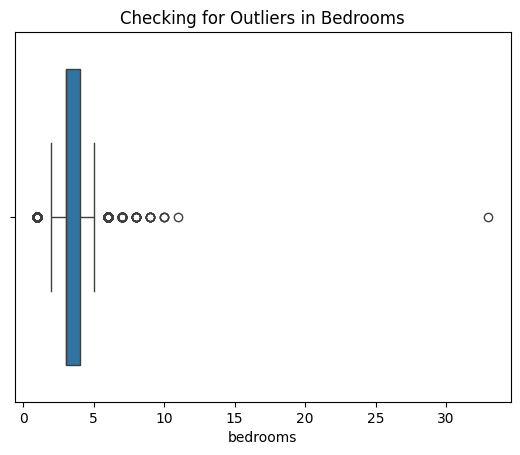

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df_property['bedrooms'])
plt.title("Checking for Outliers in Bedrooms")
plt.show()

In [61]:
# Identify and fix the outlier in the 'bedrooms' column
# We change 33 to 3 because a 1,620 sqft house cannot realistically have 33 bedrooms
df_property.loc[df_property['bedrooms'] == 33, 'bedrooms'] = 3

In [62]:
#Verification: Check the new maximum value
print("New Maximum Bedrooms:", df_property['bedrooms'].max())

New Maximum Bedrooms: 11.0


In [63]:
# Check if there are any 0-bedroom houses that might need fixing
zero_bedrooms = df_property[df_property['bedrooms'] == 0]
print(f"Houses with 0 bedrooms: {len(zero_bedrooms)}")

Houses with 0 bedrooms: 0


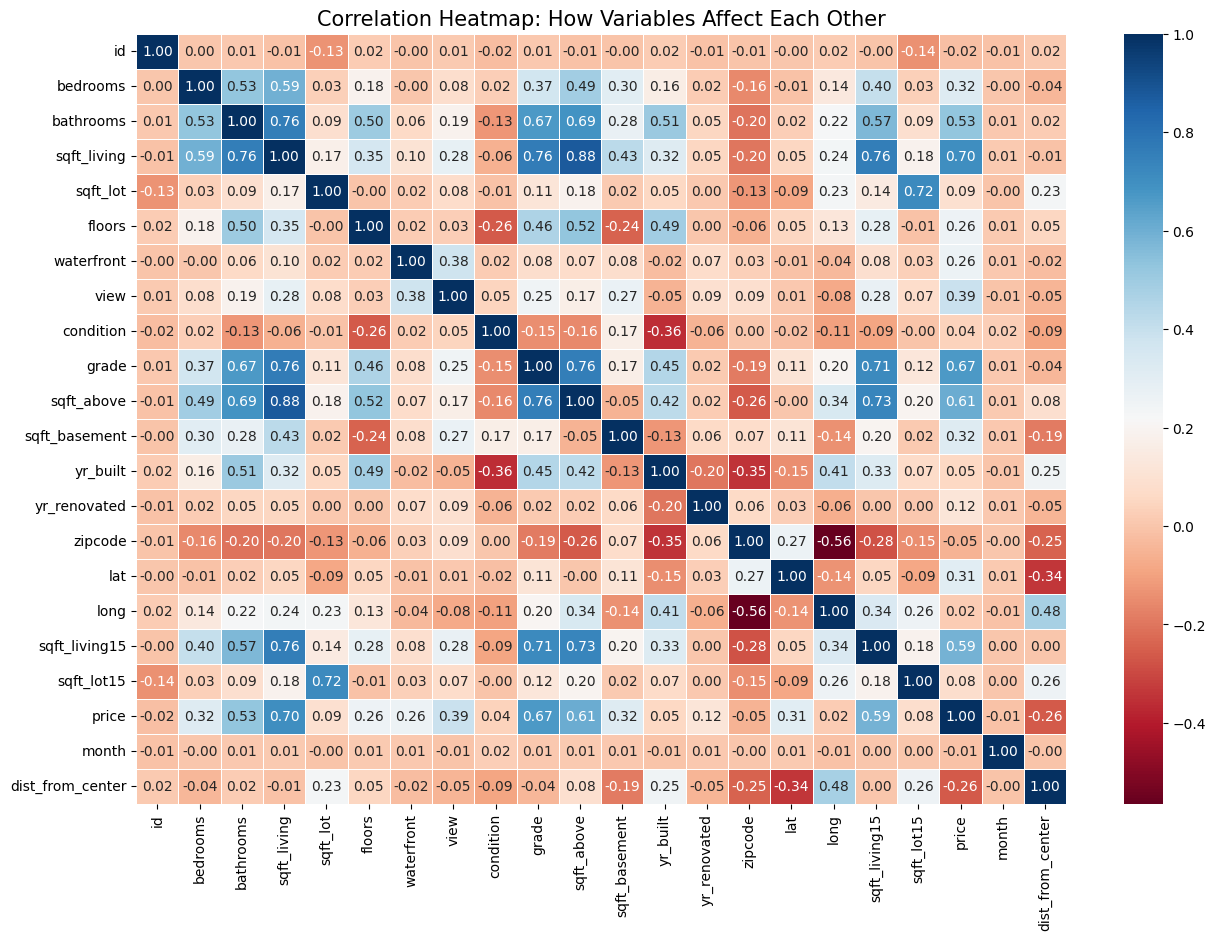

In [64]:
# 1. Select only numerical columns for correlation
numerical_df = df_property.select_dtypes(include=[np.number])

# 2. Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap: How Variables Affect Each Other", fontsize=15)
plt.show()

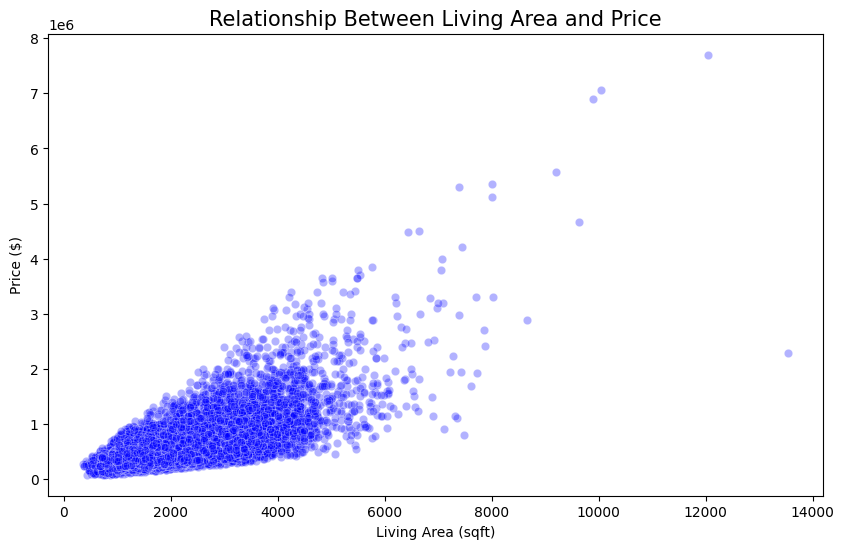

In [65]:
plt.figure(figsize=(10, 6))
# We use alpha=0.3 to see where data "piles up"
sns.scatterplot(data=df_property, x='sqft_living', y='price', alpha=0.3, color='blue')
plt.title("Relationship Between Living Area and Price", fontsize=15)
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price ($)")
plt.show()

/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_9595/3721129604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_property, x='waterfront', y='price', palette='Set2')


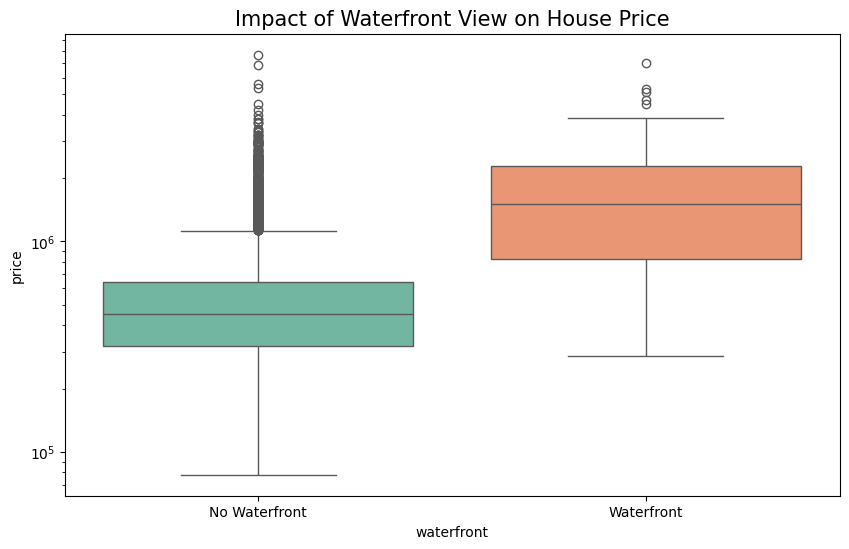

In [66]:
plt.figure(figsize=(10, 6))
# Comparing prices for houses with vs. without a waterfront
sns.boxplot(data=df_property, x='waterfront', y='price', palette='Set2')
plt.title("Impact of Waterfront View on House Price", fontsize=15)
plt.xticks([0, 1], ['No Waterfront', 'Waterfront'])
plt.yscale('log') # Using log scale because waterfront prices are much higher
plt.show()

/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_9595/1544446994.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


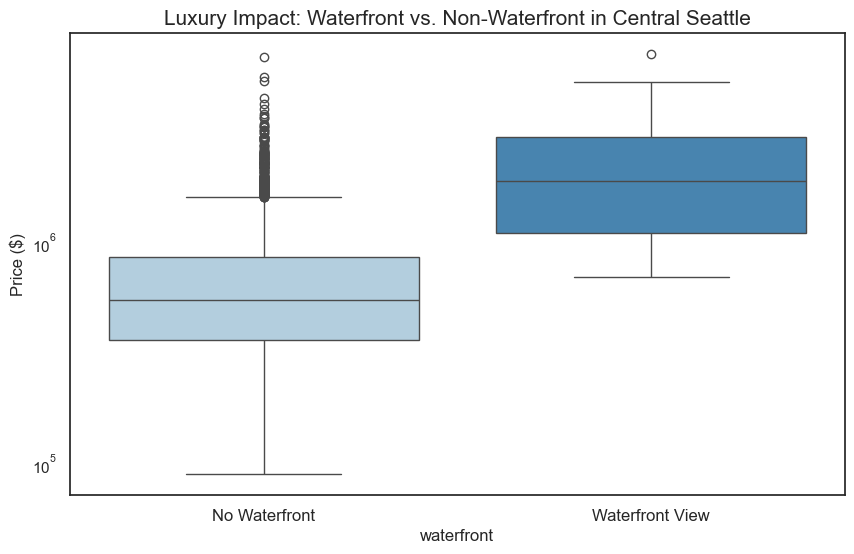

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate the "Central Area" first
# Using the same distance threshold (0.1) we used before
central_houses = df_property[df_property['dist_from_center'] < 0.1].copy()

# 2. Statistics: Calculate the specific average prices
waterfront_stats = central_houses.groupby('waterfront')['price'].mean()

# 3. Visualization: Boxplot to show the extreme premium
plt.figure(figsize=(10, 6))

# Boxplots are better here because waterfront properties often have huge price outliers
sns.boxplot(
    data=central_houses, 
    x='waterfront', 
    y='price', 
    palette='Blues'
)

# 4. Polish the graph for Timothy
plt.title("Luxury Impact: Waterfront vs. Non-Waterfront in Central Seattle", fontsize=15)
plt.xticks([0, 1], ['No Waterfront', 'Waterfront View'], fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.yscale('log') # Note: I use a log scale because the price gap is likely massive
plt.show()

/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_9595/2064024809.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


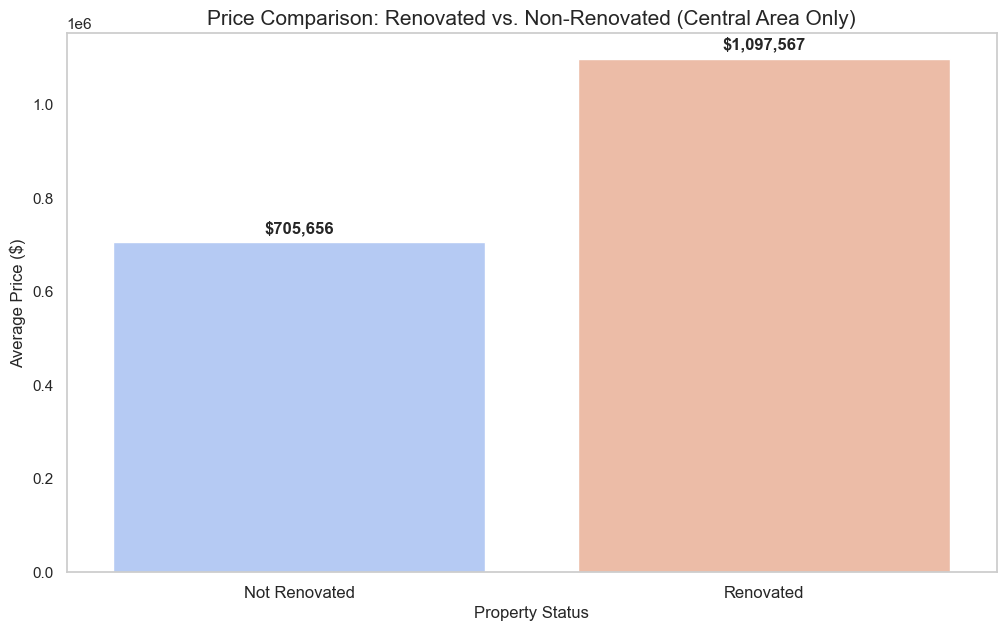

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter the data for the "Central Area" 
# We define 'Central' as houses within 0.1 degrees of the geographic center
central_houses = df_property[df_property['dist_from_center'] < 0.1]

# 2. Create the Comparison Graph
plt.figure(figsize=(12, 7))

# We use a Bar Plot to compare the Average (Mean) prices clearly
sns.barplot(
    data=central_houses, 
    x='is_renovated', 
    y='price', 
    palette='coolwarm',
    errorbar=None  # Set to None for a cleaner view of the averages
)

# 3. Add labels that make sense for Timothy
plt.title("Price Comparison: Renovated vs. Non-Renovated (Central Area Only)", fontsize=15)
plt.xticks([0, 1], ['Not Renovated', 'Renovated'], fontsize=12)
plt.ylabel("Average Price ($)", fontsize=12)
plt.xlabel("Property Status", fontsize=12)

# 4. Optional: Add the actual price numbers on top of the bars
for i, p in enumerate(central_houses.groupby('is_renovated')['price'].mean()):
    plt.text(i, p + 20000, f'${p:,.0f}', ha='center', fontweight='bold')
plt.grid(False)
plt.show()

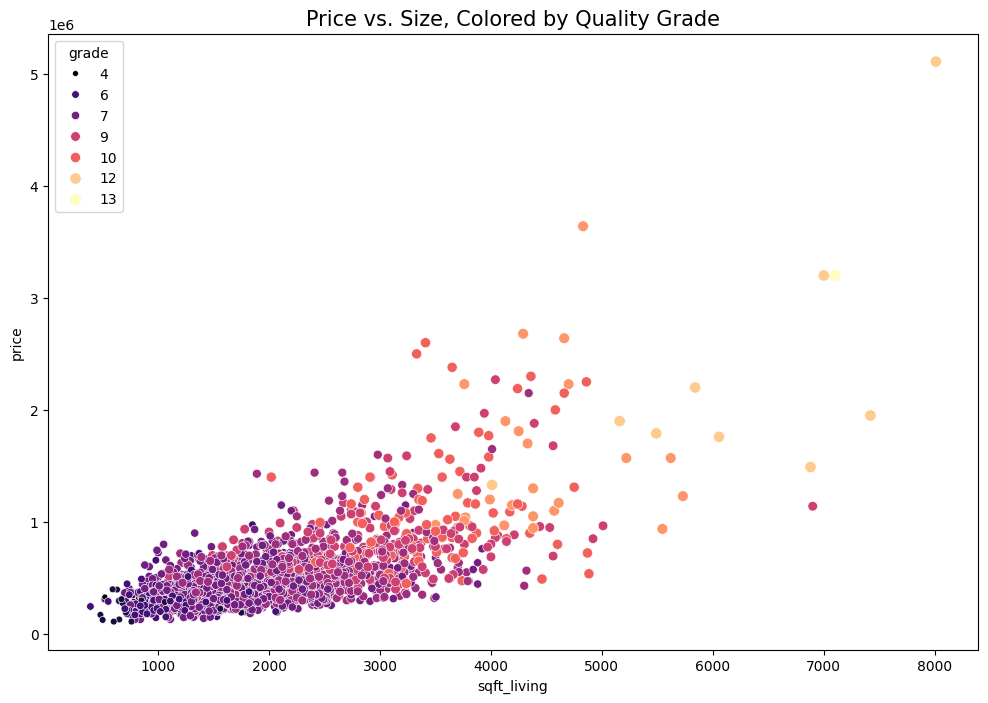

In [68]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_property.sample(2000), x='sqft_living', y='price', hue='grade', palette='magma', size='grade')
plt.title("Price vs. Size, Colored by Quality Grade", fontsize=15)
plt.show()

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

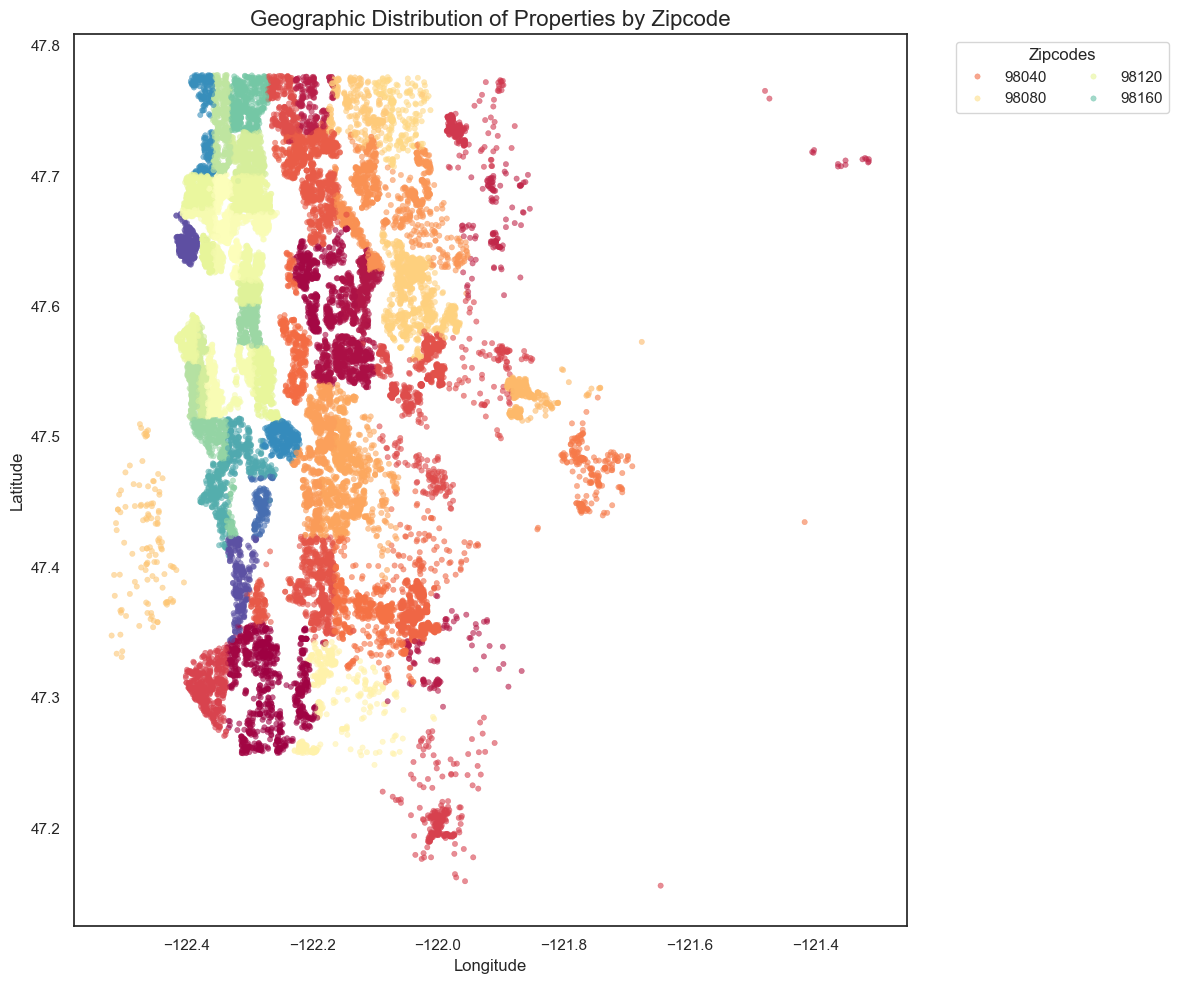

In [70]:
#Set the style for a professional research look
sns.set_theme(style="white")
plt.figure(figsize=(12, 10))

#Create the "Map" using a scatter plot
# We use Longitude for X and Latitude for Y to mirror a real map
# 'hue' is set to zipcode to see the neighborhood clusters
map_plot = sns.scatterplot(
    data=df_property, 
    x='long', 
    y='lat', 
    hue='zipcode', 
    palette='Spectral', 
    alpha=0.6, 
    s=15, 
    edgecolor=None
)

#Final Polish
plt.title('Geographic Distribution of Properties by Zipcode', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Move the legend outside so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Zipcodes', ncol=2)

plt.tight_layout()
plt.show()

In [193]:
%pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [folium]
Note: you may need to restart the kernel to use updated packages.


In [192]:
import folium

# Create a map centered on your dataset's center
m = folium.Map(location=[df['lat'].median(), df['long'].median()], zoom_start=10)

# Add a few sample points to the map
for i in range(0, 100): # Just plotting first 100 for speed
    folium.CircleMarker(
        location=[df_property.iloc[i]['lat'], df.iloc[i]['long']],
        radius=5,
        color='blue',
        fill=True
    ).add_to(m)

m # This will render an interactive map inside VS Code

--- PROVING HYPOTHESIS 1: RENOVATION Return On Investment ---
Sample Size: 986 high-grade central houses.
Average Price (Not Renovated): $1,295,447.38
Average Price (Renovated): $1,719,237.50
RESULT: The Renovation Premium is $423,790.12 (32.7% increase).


/var/folders/pd/d5ktqt997j9bscgy1kmsvw1r0000gn/T/ipykernel_9595/2026523056.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=h1_segment, x='is_renovated', y='price', palette='RdBu_r')


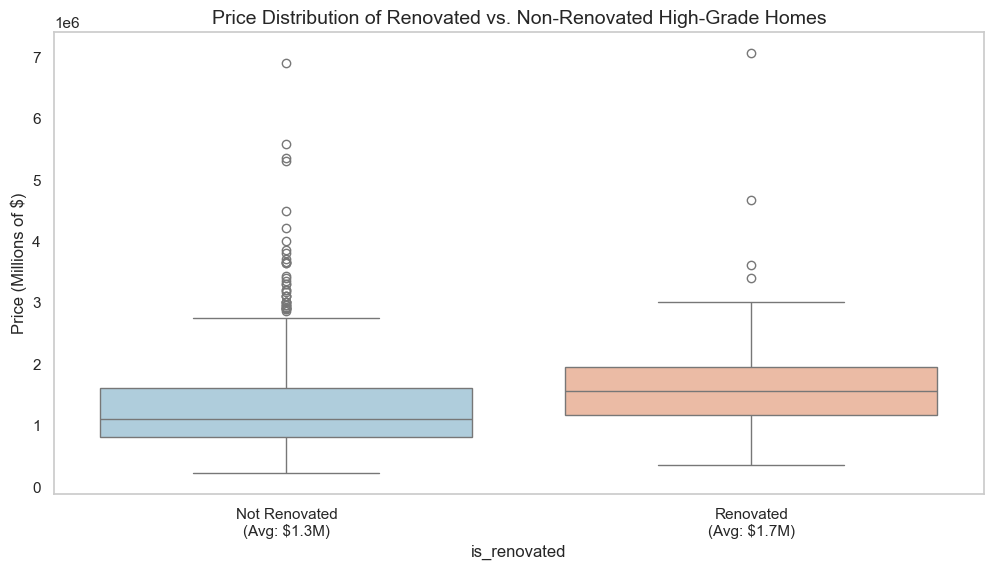

In [114]:
#Hypothesis 1 Code- Timothy should renovate Houses to get better Price of his properties.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Clean
df_property['is_renovated'] = df_property['yr_renovated'] > 0

#Define the "Center" and filter for Timothy's High-Grade Segment
center_lat = df_property['lat'].median() 
center_long = df_property['long'].median()
df_property['dist_from_center'] = np.sqrt((df_property['lat'] - center_lat)**2 + (df_property['long'] - center_long)**2)

# HYPOTHESIS 1 SEGMENT: Central (dist < 0.1) AND Grade >= 9
h1_segment = df_property[(df_property['dist_from_center'] < 0.1) & (df_property['grade'] >= 9)].copy()

# 3. Calculate Statistical Metrics
stats_h1 = h1_segment.groupby('is_renovated')['price'].agg(['mean', 'median', 'count', 'std']).reset_index()

# 4. Calculate the "Price Premium"
not_renovated_avg = stats_h1.loc[stats_h1['is_renovated'] == False, 'mean'].values[0]
renovated_avg = stats_h1.loc[stats_h1['is_renovated'] == True, 'mean'].values[0]
premium_dollars = renovated_avg - not_renovated_avg
premium_percent = (premium_dollars / not_renovated_avg) * 100

print(f"--- PROVING HYPOTHESIS 1: RENOVATION Return On Investment ---")
print(f"Sample Size: {len(h1_segment)} high-grade central houses.")
print(f"Average Price (Not Renovated): ${not_renovated_avg:,.2f}")
print(f"Average Price (Renovated): ${renovated_avg:,.2f}")
print(f"RESULT: The Renovation Premium is ${premium_dollars:,.2f} ({premium_percent:.1f}% increase).")

# 5. Visualization for Timothy Stevens
plt.figure(figsize=(12, 6))

# Boxplot shows the spread and the "Premium" jump clearly
sns.boxplot(data=h1_segment, x='is_renovated', y='price', palette='RdBu_r')
plt.title("Price Distribution of Renovated vs. Non-Renovated High-Grade Homes", fontsize=14)
plt.xticks([0, 1], [f'Not Renovated\n(Avg: ${not_renovated_avg/1e6:.1f}M)', f'Renovated\n(Avg: ${renovated_avg/1e6:.1f}M)'])
plt.ylabel("Price (Millions of $)")

plt.grid(False)
plt.show()

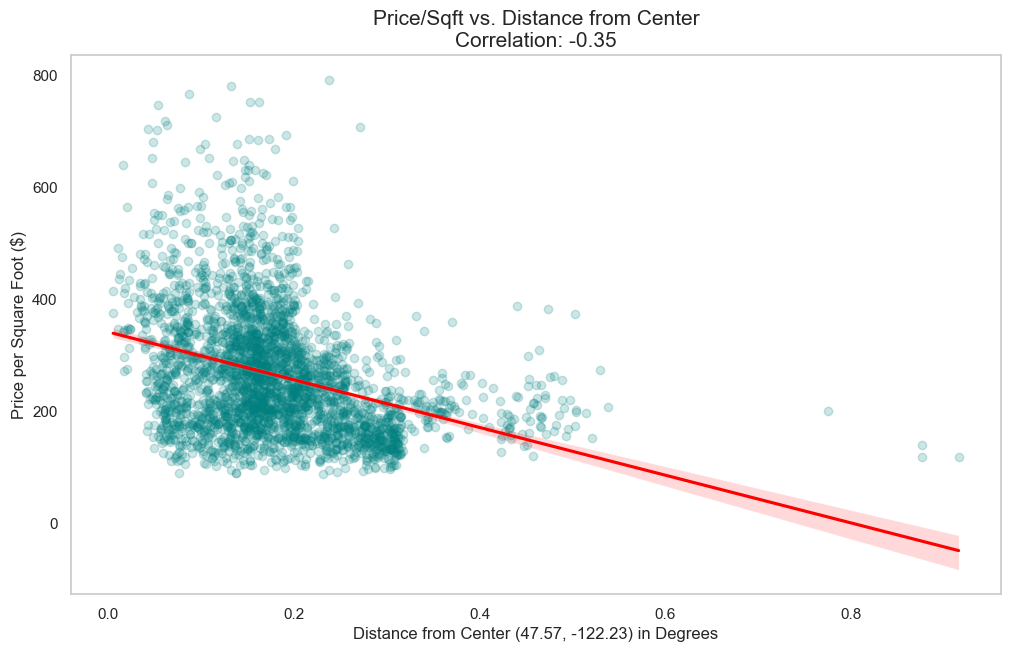

In [115]:
#Hypotheses 2 -- Timothy can get good price as the central poroperties have highest price per square foot.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Feature Engineering: Create the dependent variable
df_property['price_per_sqft'] = df_property['price'] / df_property['sqft_living']

# 2. Define Timothy's target coordinates
target_lat = 47.57
target_long = -122.23

# 3. Calculate distance from every house to this target point
# We use Euclidean distance as a proxy for physical distance in degrees
df_property['dist_to_target'] = np.sqrt(
    (df_property['lat'] - target_lat)**2 + 
    (df_property['long'] - target_long)**2
)

# 4. Statistical Test (Pearson Correlation)
# This checks if distance and price-per-sqft move together
corr, _ = pearsonr(df_property['dist_to_target'], df_property['price_per_sqft'])

# 5. Visualization: Regression Plot
plt.figure(figsize=(12, 7))
sns.regplot(
    data=df_property.sample(3000), # Sample for faster rendering
    x='dist_to_target', 
    y='price_per_sqft', 
    scatter_kws={'alpha':0.2, 'color':'teal'}, 
    line_kws={'color':'red'}
)

plt.title(f"Price/Sqft vs. Distance from Center\nCorrelation: {corr:.2f}", fontsize=15)
plt.xlabel("Distance from Center (47.57, -122.23) in Degrees")
plt.ylabel("Price per Square Foot ($)")
plt.grid(False)
plt.show()

--- Seasonal Analysis ---
Spring Average Price: $552,782.76
Winter Average Price: $519,613.65
The 'Spring Premium' is: $33,169.12 (6.38%)


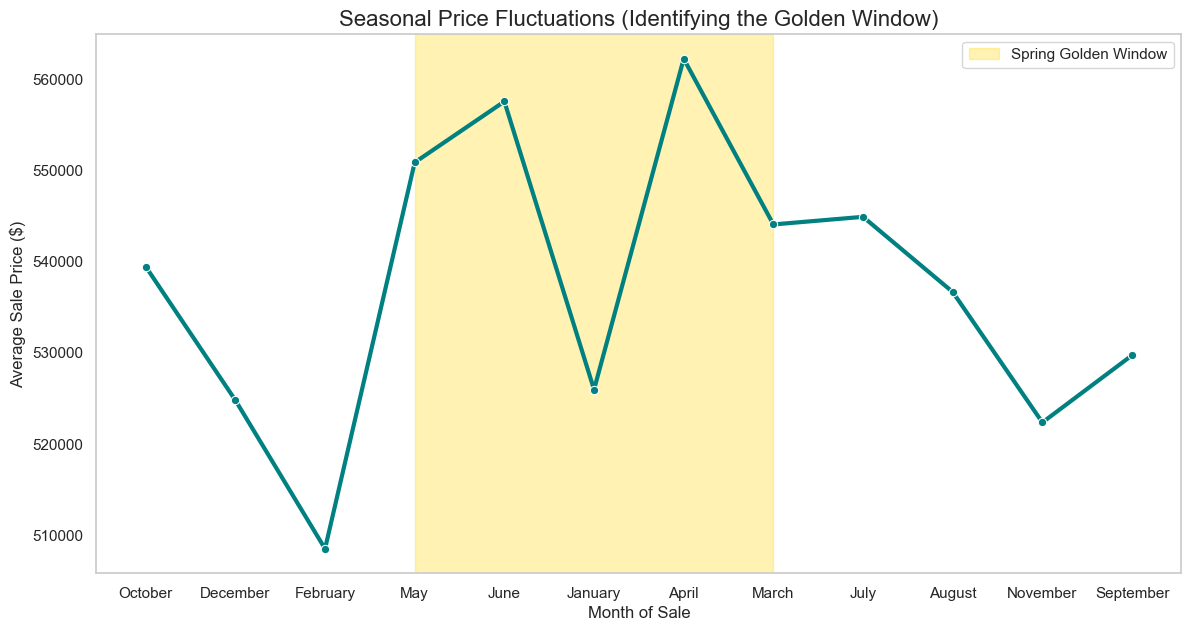

In [117]:
#Hypotheses 3 - Timothy should finish his renovation by February and list his central properties in Spring to get more prices.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure 'date' is in datetime format and extract months
df_property['date'] = pd.to_datetime(df_property['date'])
df_property['month'] = df_property['date'].dt.month
df_property['month_name'] = df_property['date'].dt.month_name()

# 2. Define our "Seasons" based on Timothy's Hypothesis
# Spring/Golden Window: March, April, May
# Winter: December, January, February
def define_season(month):
    if month in [3, 4, 5]:
        return 'Spring (Golden Window)'
    elif month in [12, 1, 2]:
        return 'Winter'
    else:
        return 'Other'

df_property['season'] = df_property['month'].apply(define_season)

# 3. Calculate the Price Difference
season_stats = df_property[df_property['season'] != 'Other'].groupby('season')['price'].mean()
spring_avg = season_stats['Spring (Golden Window)']
winter_avg = season_stats['Winter']
price_diff = spring_avg - winter_avg
percent_increase = (price_diff / winter_avg) * 100

print(f"--- Seasonal Analysis ---")
print(f"Spring Average Price: ${spring_avg:,.2f}")
print(f"Winter Average Price: ${winter_avg:,.2f}")
print(f"The 'Spring Premium' is: ${price_diff:,.2f} ({percent_increase:.2f}%)")

# 4. Visualization: Monthly Trend and Seasonal Highlight
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Create a Line Plot of average price by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

sns.lineplot(data=df_property, x='month_name', y='price', estimator='mean', 
             errorbar=None, marker='o', linewidth=3, color='teal', sort=False)

# Highlight the "Golden Window"
plt.axvspan('March', 'May', color='gold', alpha=0.3, label='Spring Golden Window')

plt.title("Seasonal Price Fluctuations (Identifying the Golden Window)", fontsize=16)
plt.ylabel("Average Sale Price ($)", fontsize=12)
plt.xlabel("Month of Sale", fontsize=12)
plt.legend()
plt.grid(False)
plt.show()

In [95]:
import pandas as pd
import folium

# 1. Filter for a small subset of Central properties
# We take the top 10 most expensive properties in the center to keep the map clean
central_top_10 = df_property[df_property['dist_from_center'] < 0.05].sort_values(by='price', ascending=False).head(10)

# 2. Create a list of coordinates (Lat, Long pairs) for the line
# Folium needs a list of lists: [[lat1, lon1], [lat2, lon2], ...]
line_coordinates = central_top_10[['lat', 'long']].values.tolist()

# 3. Initialize the map at the center point
m = folium.Map(location=[47.57, -122.23], zoom_start=13)

# 4. Add markers for the properties
for i, row in central_top_10.iterrows():
    folium.Marker(
        location=[row['lat'], row['long']],
        popup=f"Price: ${row['price']:,.0f}",
        icon=folium.Icon(color='blue', icon='home')
    ).add_to(m)

# 5. Connect the dots with a PolyLine
folium.PolyLine(
    locations=line_coordinates,
    color="red",
    weight=2.5,
    opacity=0.8,
    tooltip="Connection Path"
).add_to(m)

# 6. Display the map
m

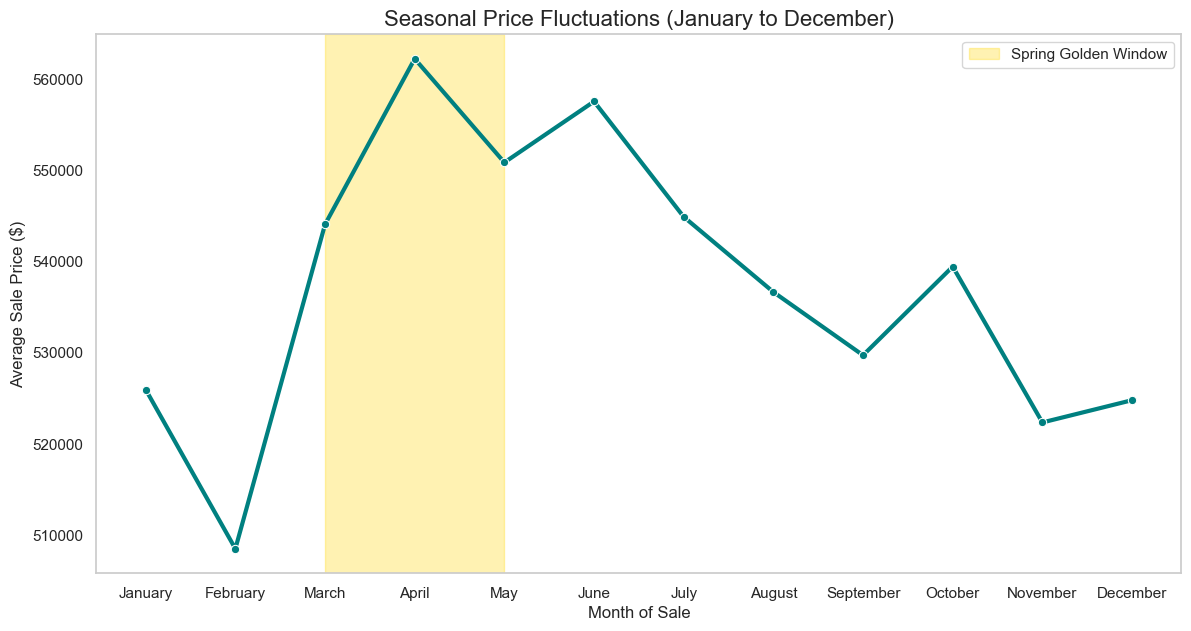

In [120]:
# 1. Group the data by month to get one average price per month
# This ensures we don't have multiple overlapping data points for the same month across different years
monthly_avg = df_property.groupby(['month', 'month_name'])['price'].mean().reset_index()

# 2. Sort explicitly by the numerical month (1-12)
monthly_avg = monthly_avg.sort_values('month')

# 3. Visualization
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Use monthly_avg instead of df_property to ensure only one point per month is plotted
sns.lineplot(data=monthly_avg, x='month_name', y='price', 
             marker='o', linewidth=3, color='teal', sort=False)

# Highlight the "Golden Window" (March to May)
plt.axvspan('March', 'May', color='gold', alpha=0.3, label='Spring Golden Window')

plt.title("Seasonal Price Fluctuations (January to December)", fontsize=16)
plt.ylabel("Average Sale Price ($)", fontsize=12)
plt.xlabel("Month of Sale", fontsize=12)
plt.legend()
plt.grid(False)
plt.show()

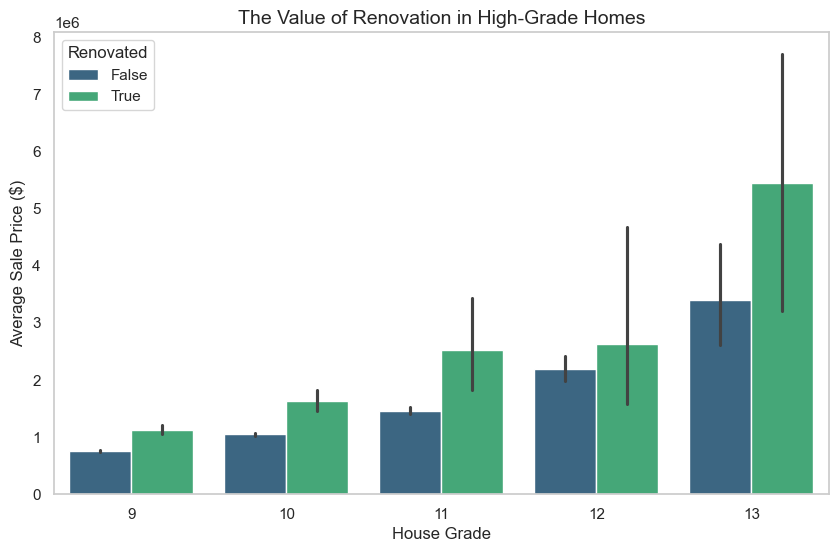

In [121]:
plt.figure(figsize=(10, 6))
# Focus on high-grade properties only
high_grade = df_property[df_property['grade'] >= 9]

sns.barplot(data=high_grade, x='grade', y='price', hue='is_renovated', palette='viridis')

plt.title("The Value of Renovation in High-Grade Homes", fontsize=14)
plt.ylabel("Average Sale Price ($)")
plt.xlabel("House Grade")
plt.legend(title='Renovated')
plt.grid(False)
plt.show()

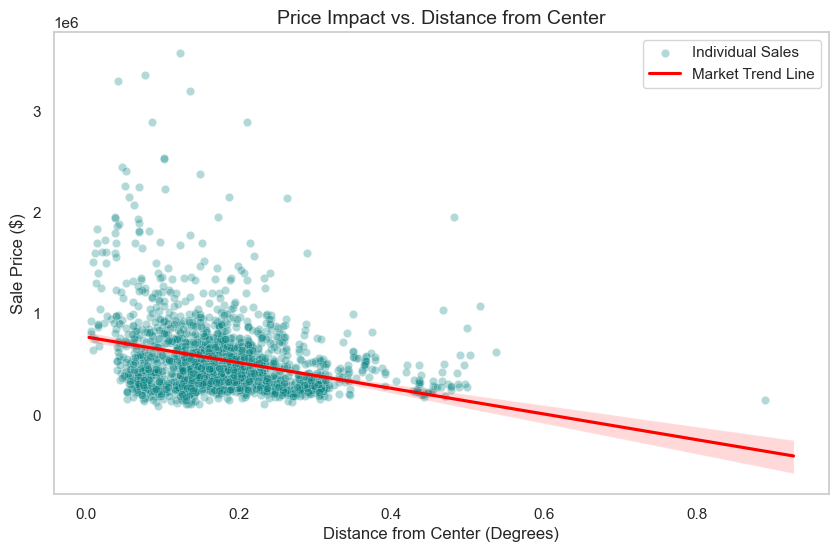

In [122]:
plt.figure(figsize=(10, 6))

# Use a sample to avoid a messy 'blob' of dots
sns.scatterplot(data=df_property.sample(2000), x='dist_from_center', y='price', 
                alpha=0.3, color='teal', label='Individual Sales')

# Add the trend line (Regression)
sns.regplot(data=df_property.sample(2000), x='dist_from_center', y='price', 
            scatter=False, color='red', label='Market Trend Line')

plt.title("Price Impact vs. Distance from Center", fontsize=14)
plt.xlabel("Distance from Center (Degrees)")
plt.ylabel("Sale Price ($)")
plt.legend()
plt.grid(False)
plt.show()

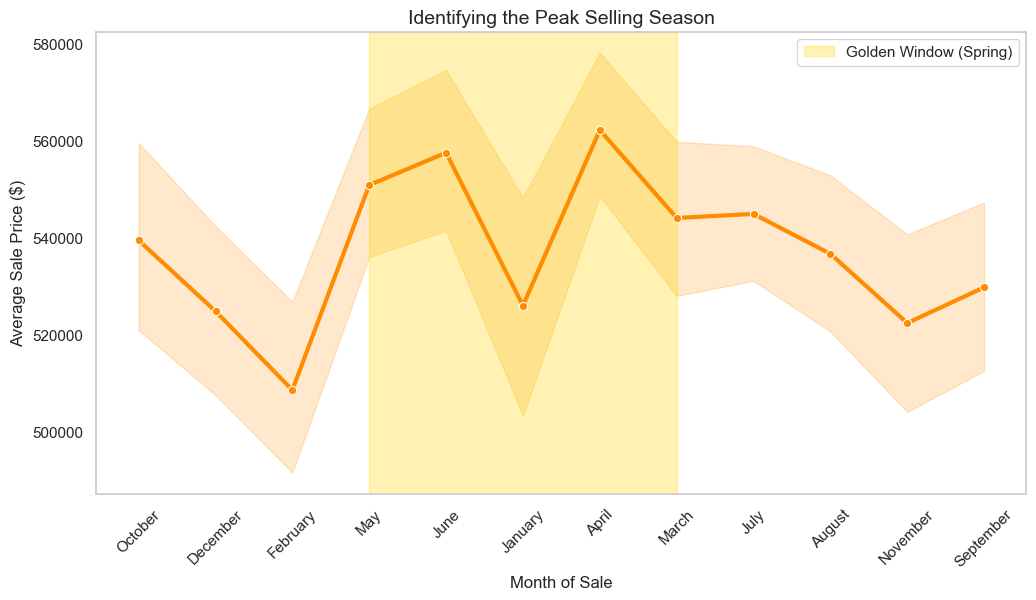

In [123]:
plt.figure(figsize=(12, 6))

# Ensure months are in the correct order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

sns.lineplot(data=df_property, x='month_name', y='price', estimator='mean', 
             marker='o', linewidth=3, color='darkorange', sort=False)

# Use preattentive attributes: the Gold highlight
plt.axvspan('March', 'May', color='gold', alpha=0.3, label='Golden Window (Spring)')

plt.title("Identifying the Peak Selling Season", fontsize=14)
plt.xlabel("Month of Sale")
plt.ylabel("Average Sale Price ($)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(False)
plt.show()

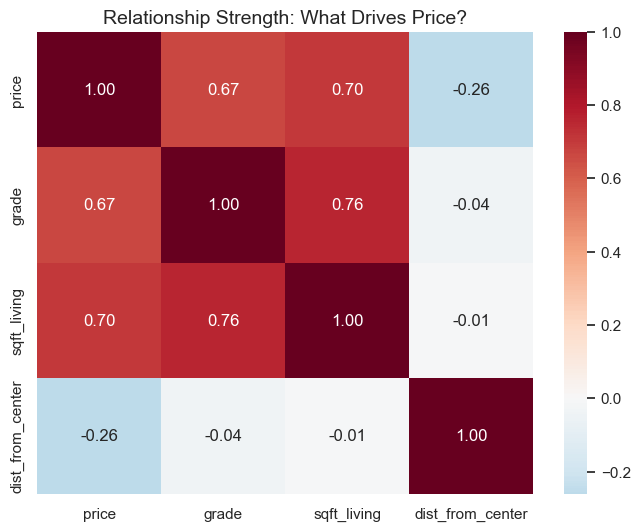

In [101]:
plt.figure(figsize=(8, 6))

# Check relationship between key variables
corr_matrix = df_property[['price', 'grade', 'sqft_living', 'dist_from_center']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Relationship Strength: What Drives Price?", fontsize=14)
plt.show()

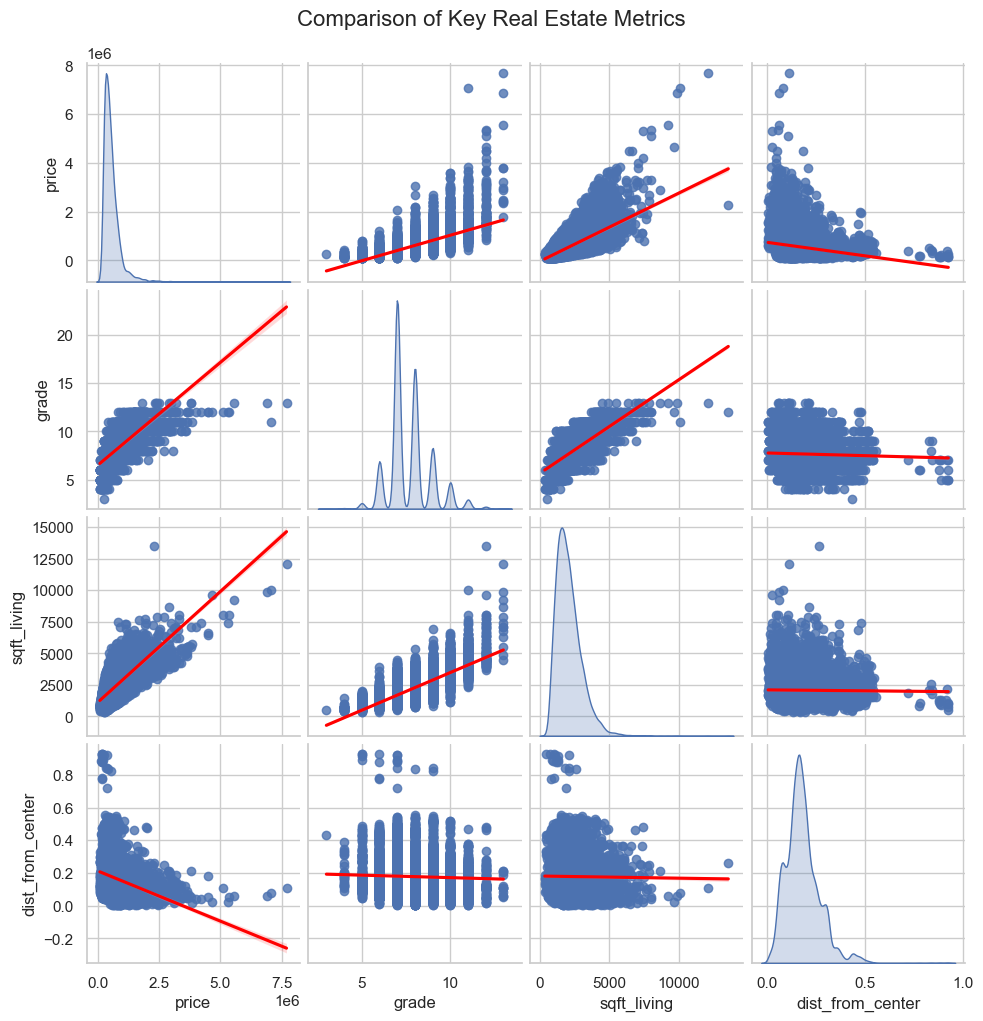

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the most important columns for Timothy's strategy
# We include 'price' to see how everything else impacts his profit
cols_to_compare = ['price', 'grade', 'sqft_living', 'dist_from_center']

# Use sns.pairplot for an all-in-one comparison
# 'kind=reg' adds a trend line to every scatter plot to show direction
sns.pairplot(df_property[cols_to_compare], kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}})

plt.suptitle("Comparison of Key Real Estate Metrics", y=1.02, fontsize=16)
plt.show()

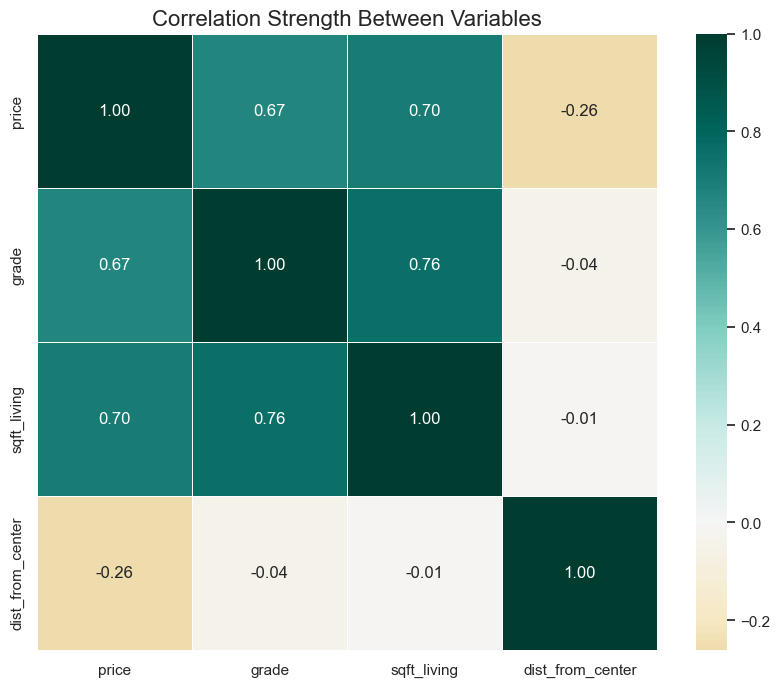

In [104]:
plt.figure(figsize=(10, 8))

# Calculate the correlation coefficients
correlation_data = df_property[cols_to_compare].corr()

# Create a heatmap
sns.heatmap(correlation_data, annot=True, cmap='BrBG', center=0, fmt=".2f", linewidths=0.5)

plt.title("Correlation Strength Between Variables", fontsize=16)
plt.show()

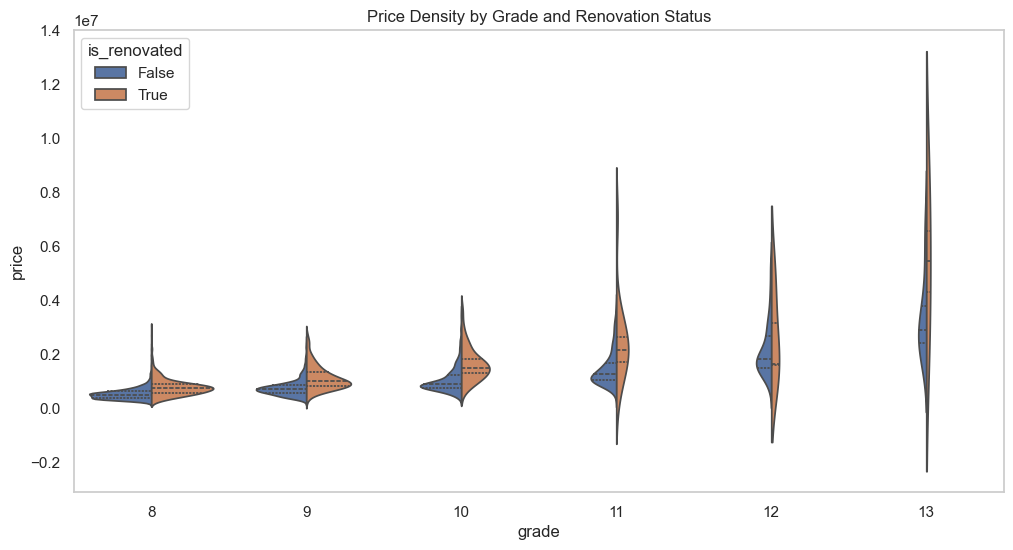

In [124]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df_property[df_property['grade'] >= 8], 
               x='grade', y='price', hue='is_renovated', split=True, inner="quart")
plt.title("Price Density by Grade and Renovation Status")
plt.grid(False)
plt.show()

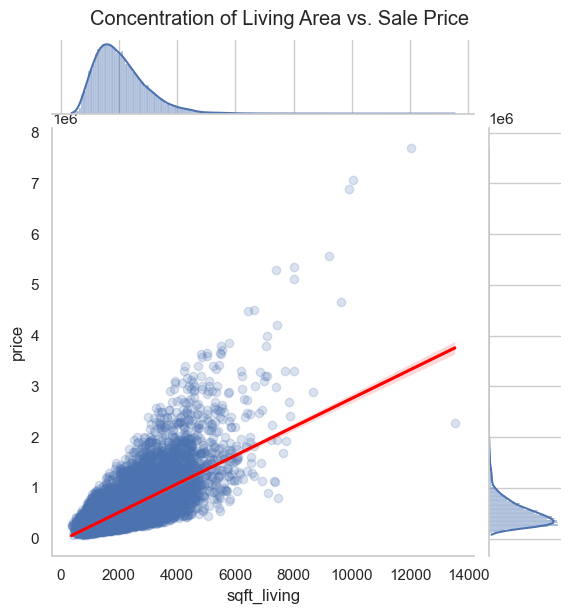

In [125]:
sns.jointplot(data=df_property, x='sqft_living', y='price', kind='reg', 
              joint_kws={'line_kws':{'color':'red'}}, scatter_kws={'alpha': 0.2})
plt.suptitle("Concentration of Living Area vs. Sale Price", y=1.02)
plt.grid(False)
plt.show()

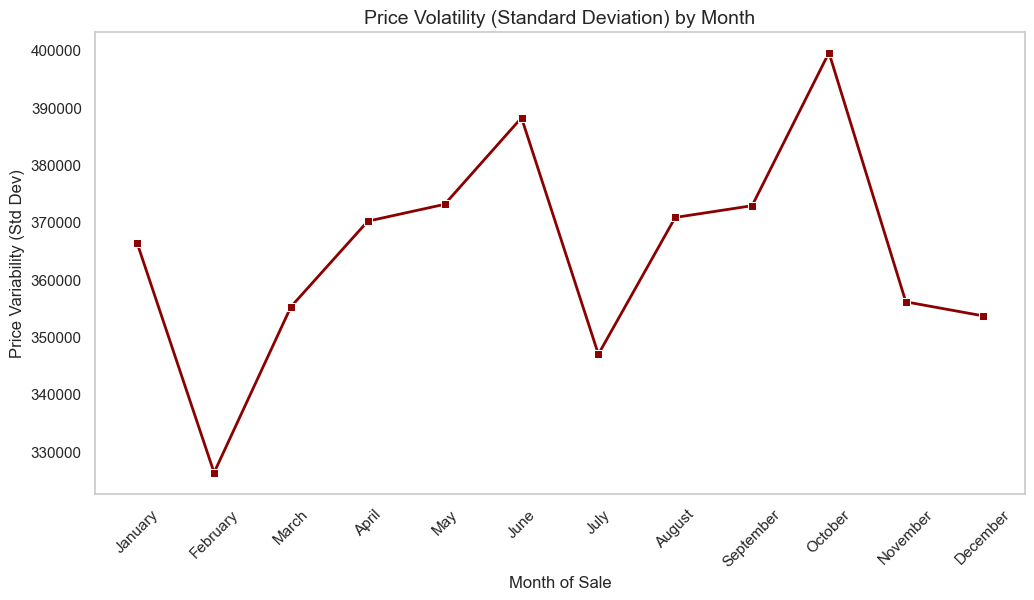

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns
import calendar  # <--- Import the calendar module here

# 1. Group by month and calculate the Standard Deviation (Spread of prices)
# This shows how much prices "swing" in a given month
monthly_std = df_property.groupby('month')['price'].std().reset_index()

# 2. Use calendar to map numbers (1-12) to Month Names
# .month_name[x] converts 1 to 'January', 2 to 'February', etc.
monthly_std['month_name'] = monthly_std['month'].apply(lambda x: calendar.month_name[x])

# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_std, x='month_name', y='price', marker='s', color='darkred', linewidth=2)

# 4. Styling
plt.title("Price Volatility (Standard Deviation) by Month", fontsize=14)
plt.xlabel("Month of Sale", fontsize=12)
plt.ylabel("Price Variability (Std Dev)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.grid(False)
plt.show()

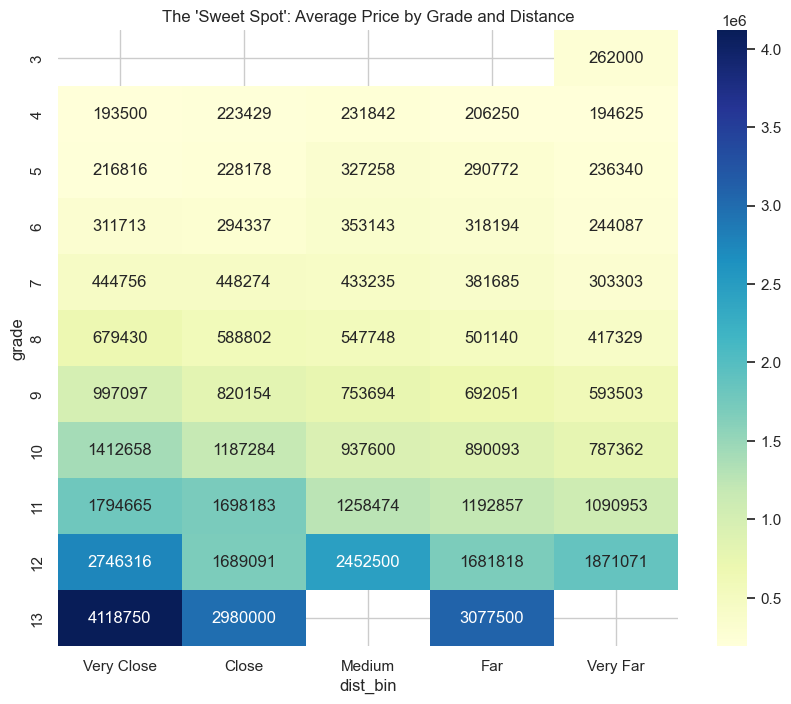

In [109]:
# Create a pivot table to see average price by Grade and Location (Binned Distance)
# We 'bin' the distance into 5 categories to make the heatmap readable
df_property['dist_bin'] = pd.qcut(df_property['dist_from_center'], q=5, labels=['Very Close', 'Close', 'Medium', 'Far', 'Very Far'])

pivot_table = df_property.pivot_table(values='price', index='grade', columns='dist_bin', aggfunc='mean')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("The 'Sweet Spot': Average Price by Grade and Distance")
plt.show()

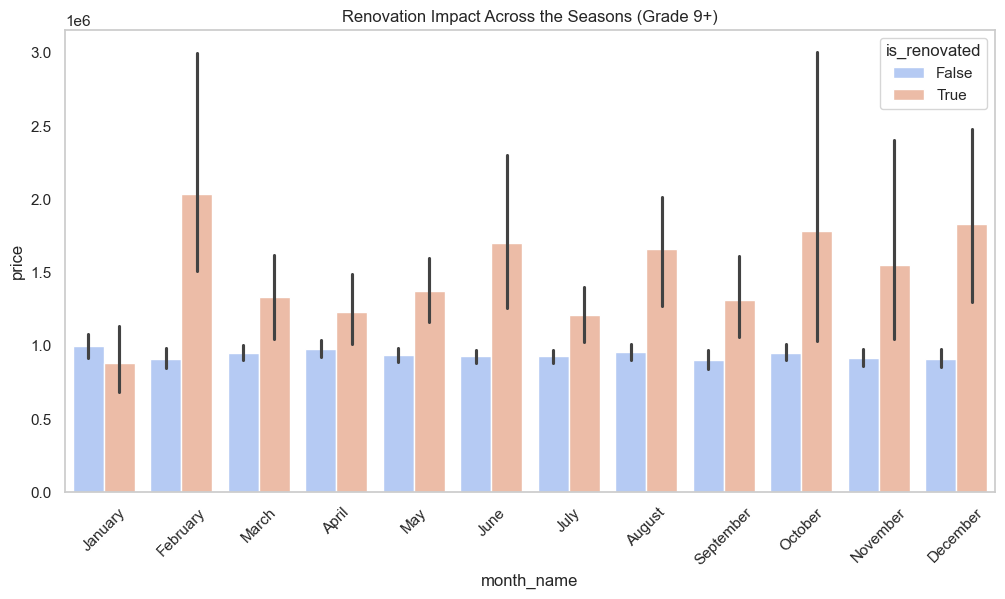

In [127]:
plt.figure(figsize=(12, 6))
# Compare Renovated vs Non-Renovated specifically across the months
sns.barplot(data=df_property[df_property['grade'] >= 9], x='month_name', y='price', 
            hue='is_renovated', palette='coolwarm', order=month_order)

plt.title("Renovation Impact Across the Seasons (Grade 9+)")
plt.xticks(rotation=45)
plt.grid(False)
plt.show()